# Results Analysis

Regenerates every figure from the saved CSVs in `notebooks/results/` (no model inference). Figures are saved to `notebooks/new_results/`.

`STT_Comparison-wPrompt wBERT.ipynb` produced the CSVs but used the earlier plotting code, so its embedded figures are outdated.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent)) #repo root, so `src` is importable from notebooks/

from src.aggregate import build_summary_report
from src.config import LATENCY_RESULTS_FILENAME, COST_EFFICIENCY_FILENAME, ACCENT_RESULTS_FILENAME, BERT_SCORES_FILENAME
from src.io_utils import load_results
from src.plots import (save_figure, plot_accuracy_latency, plot_speed_overview, plot_wer_comparison, plot_accuracy_overview,
                       plot_semantic_overview, plot_prompt_shift, plot_radar_profiles, plot_summary_table)

In [2]:
df_latency = load_results(LATENCY_RESULTS_FILENAME)
df_cost = load_results(COST_EFFICIENCY_FILENAME)
df_accent = load_results(ACCENT_RESULTS_FILENAME)
df_bert = load_results(BERT_SCORES_FILENAME)

## Part 1: Latency and cost

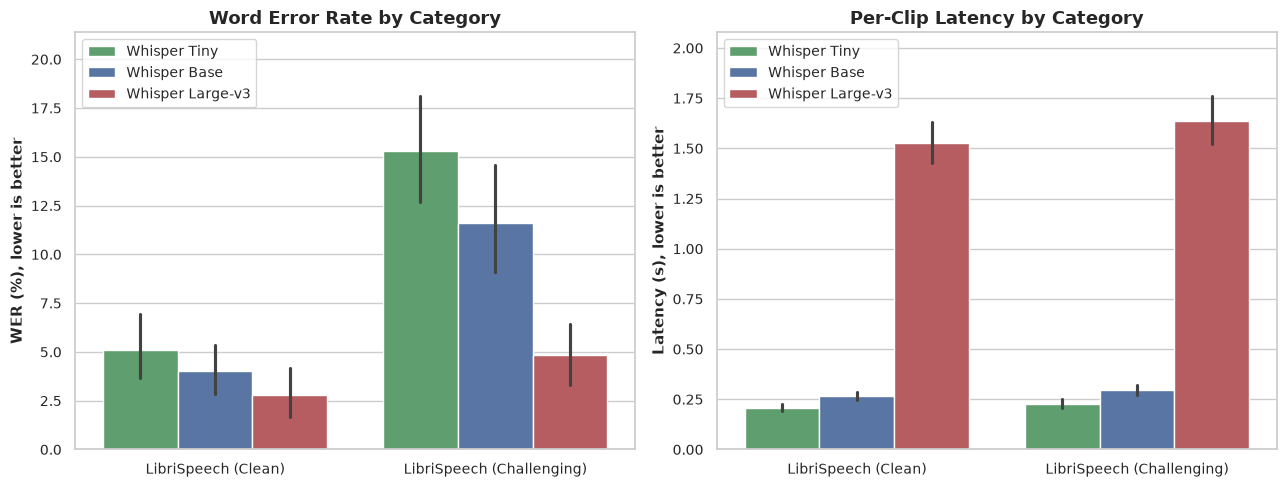

In [3]:
fig = plot_accuracy_latency(df_latency)
save_figure(fig, 'part1_accuracy_latency.png')
plt.show()

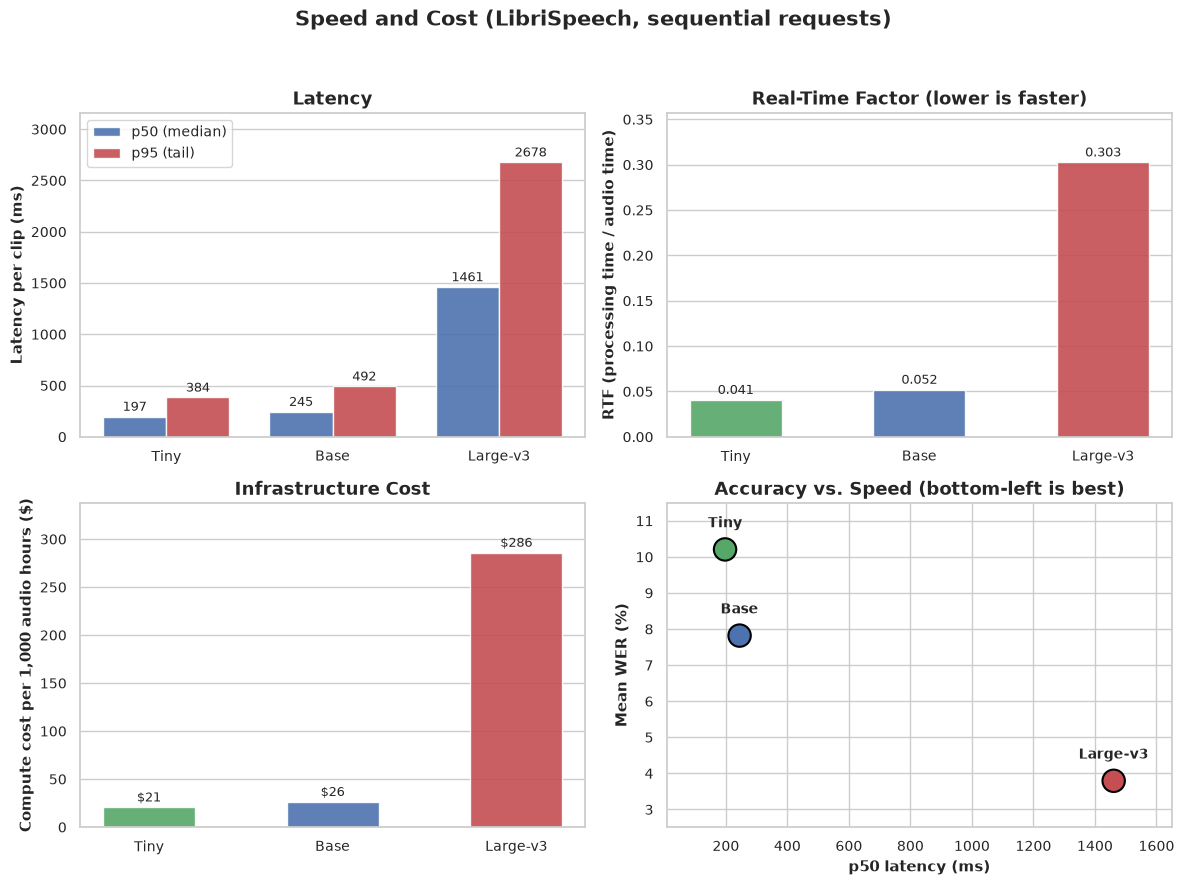

In [4]:
fig = plot_speed_overview(df_latency, df_cost)
save_figure(fig, 'speed_overview.png')
plt.show()

## Part 2: Accent robustness

Prompted WER is unbounded (looping outputs give WER in the thousands), so these figures use medians.

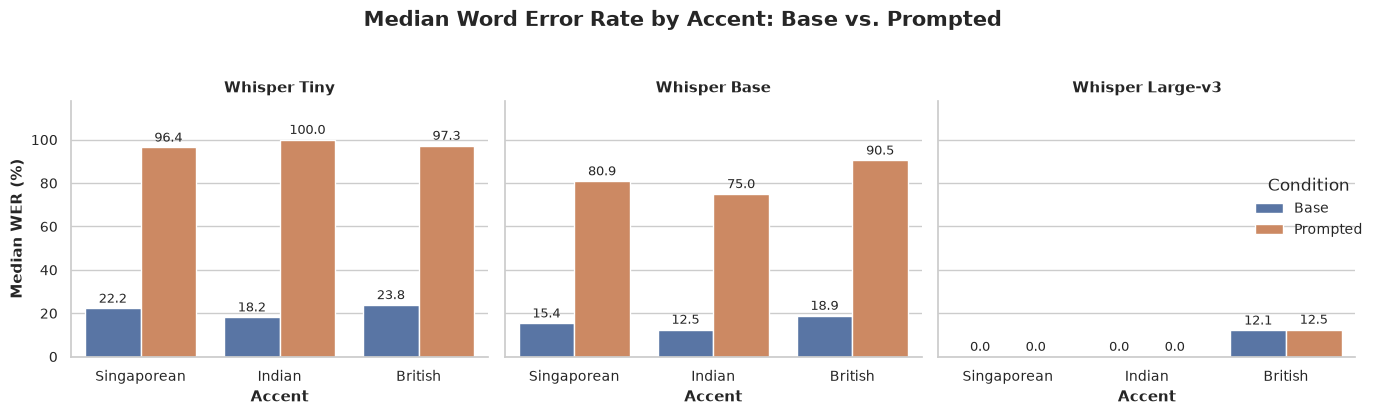

In [5]:
fig = plot_wer_comparison(df_accent)
save_figure(fig, 'wer_by_accent.png')
plt.show()

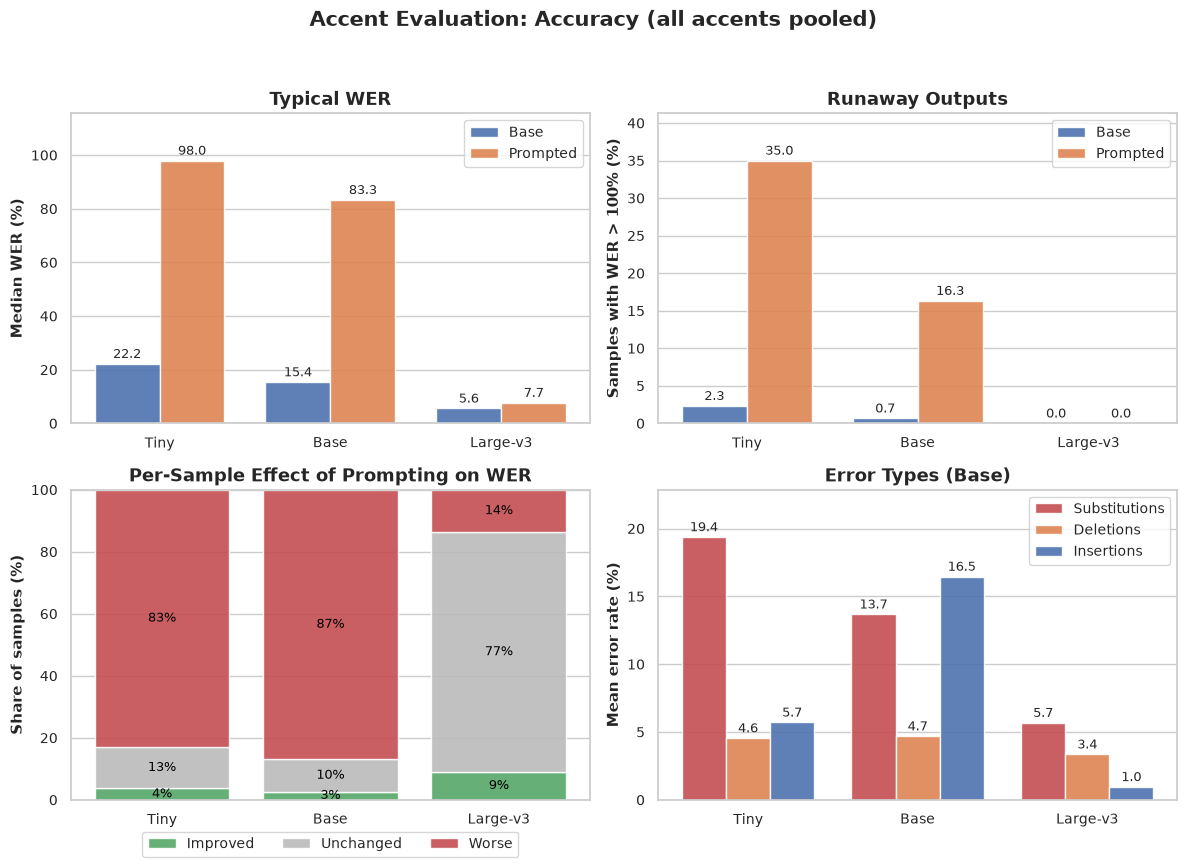

In [6]:
fig = plot_accuracy_overview(df_accent)
save_figure(fig, 'accuracy_overview.png')
plt.show()

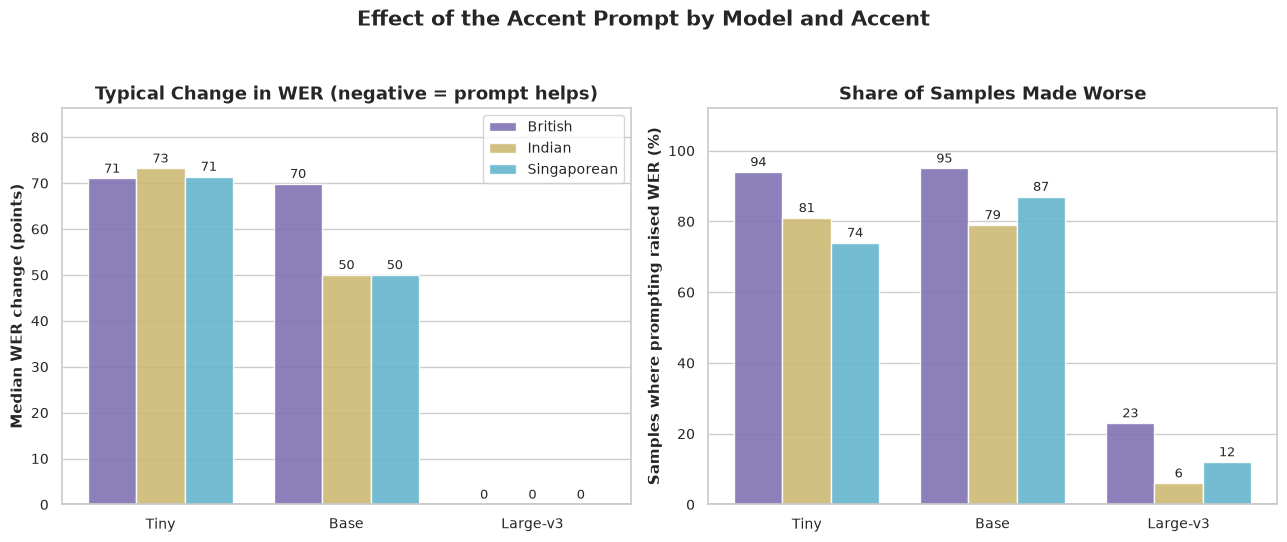

In [7]:
fig = plot_prompt_shift(df_accent)
save_figure(fig, 'prompt_shift.png')
plt.show()

## Part 3: Semantic evaluation

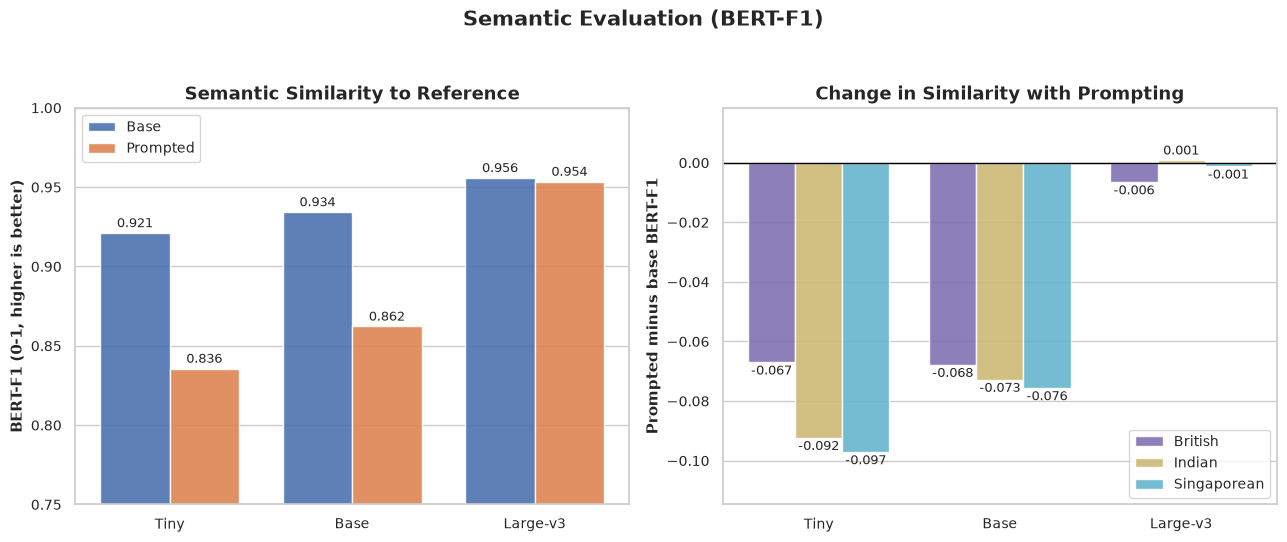

In [8]:
fig = plot_semantic_overview(df_bert)
save_figure(fig, 'semantic_overview.png')
plt.show()

## Part 4: Comparison

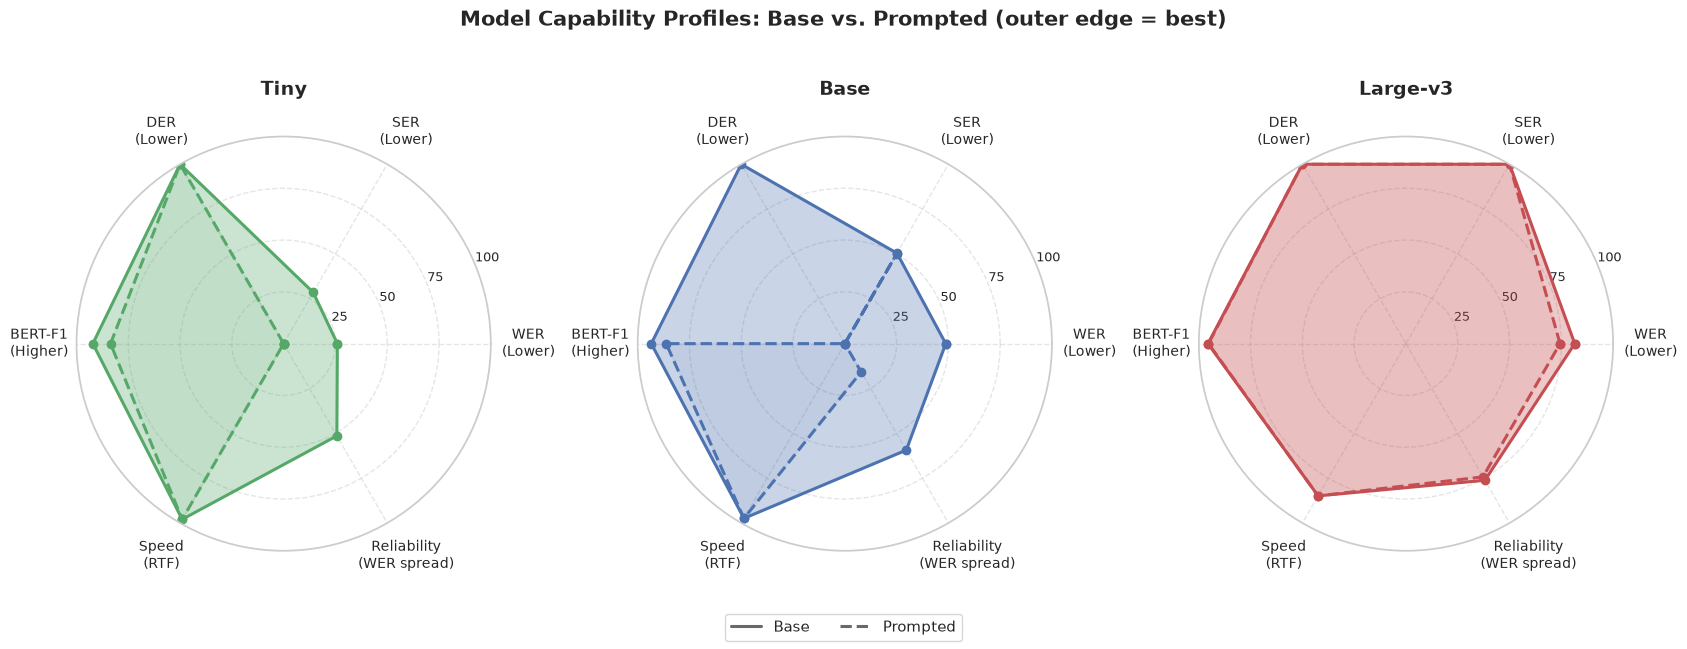

In [9]:
fig = plot_radar_profiles(df_latency, df_accent, df_bert)
save_figure(fig, 'radar_profiles.png')
plt.show()

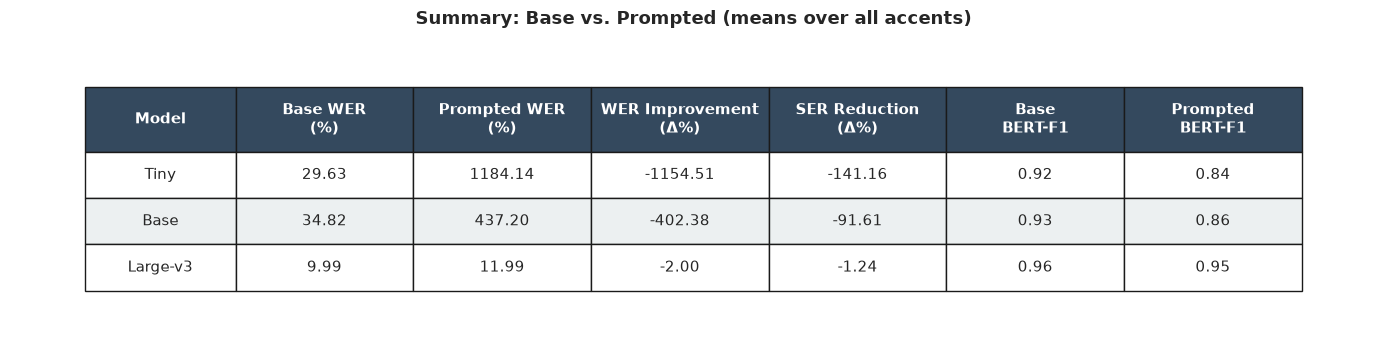

In [10]:
summary_report = build_summary_report(df_accent, df_bert)
fig = plot_summary_table(summary_report)
save_figure(fig, 'summary_table.png')
plt.show()

## Analysis: mistakes, prompting and recommendation

Everything below is computed from the saved CSVs (`notebooks/results/`); no model is re-run. Helpers live in `src/analysis.py`.

**How mistakes are counted.** Each reference/hypothesis pair is normalised exactly as the WER metric does (lower-case, punctuation removed) and aligned word by word. Every edit is then given one rule-based label:

| Label | Rule |
|---|---|
| Numeral / abbreviation | a digit on either side, or *missus/mrs*-style pairs |
| Function-word swap | both words are common function words (*and/in*, *the/a*) |
| Near-spelling variant | similarity of the two words >= 0.7 (*knight/night*, *carcases/carcasses*) |
| Different word | any other substitution |
| Dropped / Extra word | deletion / insertion |

The labels are heuristics, so treat the shares as approximate. Whole transcripts are labelled separately (see the prompt section).

In [11]:
import pandas as pd
from transformers import WhisperProcessor

from src.analysis import build_edit_table, edit_category_counts, top_confusions, output_type_counts, classify_output, pick_examples
from src.config import ACCENT_PROMPTS, MODEL_IDS, MODEL_ORDER
from src.plots import plot_edit_categories, plot_output_types

pd.set_option("display.max_colwidth", 130)
pd.set_option("display.width", 200)
df_ls = df_latency.rename(columns={"System": "Model"})

### 1. What mistakes do the three models make?

#### Part 1: LibriSpeech (read speech)

In [12]:
ls_wer = df_ls.groupby(["Model", "Category"])["WER (%)"].agg(["mean", "median"]).round(1).unstack("Model")[[("mean", m) for m in MODEL_ORDER] + [("median", m) for m in MODEL_ORDER]]
ls_wer

mean                                     median                              
Model                     Whisper Tiny Whisper Base Whisper Large-v3 Whisper Tiny Whisper Base Whisper Large-v3
Category                                                                                                       
LibriSpeech (Challenging)         15.3         11.6              4.8         12.9          8.4              0.0
LibriSpeech (Clean)                5.1          4.0              2.8          0.0          0.0              0.0

In [13]:
ls_edits = build_edit_table(df_ls, "Model", "Reference", "Hypothesis")
ls_counts = edit_category_counts(ls_edits, MODEL_ORDER)
ls_counts["Total edits"] = ls_counts.sum(axis=1)
ls_counts

Category,Numeral / abbreviation,Function-word swap,Near-spelling variant,Different word,Dropped word,Extra word,Total edits
Model,,,,,,,
Whisper Tiny,20,38,99,117,41,40,355
Whisper Base,11,21,67,99,34,31,263
Whisper Large-v3,11,8,36,36,25,4,120


In [14]:
ls_confusions = pd.concat({model: top_confusions(ls_edits, model, 6) for model in MODEL_ORDER}, names=["Model"]).reset_index(level=0)
ls_confusions

,Model,Kind,Reference word,Hypothesis word,Count
0,Whisper Tiny,substitute,and,in,6
1,Whisper Tiny,substitute,in,and,4
2,Whisper Tiny,substitute,knight,night,4
3,Whisper Tiny,substitute,thee,the,4
4,Whisper Tiny,insert,,a,3
5,Whisper Tiny,delete,a,,3
0,Whisper Base,substitute,and,in,6
1,Whisper Base,substitute,geraint,durant,4
2,Whisper Base,insert,,the,3
3,Whisper Base,insert,,up,3


In [15]:
ls_examples = pd.concat([pick_examples(df_ls, model, "WER (%)", 3) for model in MODEL_ORDER])
ls_examples[["Model", "Clip ID", "WER (%)", "Reference", "Hypothesis"]]

,Model,Clip ID,WER (%),Reference,Hypothesis
198,Whisper Tiny,ls_other_99,62.50,AND EVERY ONE ASKED THAT WHICH HE DESIRED,and everyone asks that what she desired.
181,Whisper Tiny,ls_other_82,57.14,TO GUENEVER AND HER HANDMAIDENS SAID HE,"To quiver in her hand, maiden said he."
136,Whisper Tiny,ls_other_37,50.00,ABAFT THE FORE HATCH IS THE ICE HOUSE,About the 4 hatch is the A-SOS.
381,Whisper Base,ls_other_82,85.71,TO GUENEVER AND HER HANDMAIDENS SAID HE,to Gwent over in her hand made and said he.
398,Whisper Base,ls_other_99,62.50,AND EVERY ONE ASKED THAT WHICH HE DESIRED,and everyone asks that what she desired.
306,Whisper Base,ls_other_7,50.00,THEN GERAINT WENT TO SEE ERBIN,Then your aunt went to see urban.
454,Whisper Large-v3,ls_clean_55,44.44,THREE O'CLOCK CAME FOUR FIVE SIX AND NO LETTER,"3 o'clock came, 4, 5, 6, and no letter."
536,Whisper Large-v3,ls_other_37,37.50,ABAFT THE FORE HATCH IS THE ICE HOUSE,Above the forehatch is the ice house.
506,Whisper Large-v3,ls_other_7,33.33,THEN GERAINT WENT TO SEE ERBIN,Then Duraint went to see Urban.


**Reading the Part 1 tables**

- **Size changes how many mistakes, not which kind.** Tiny makes 355 word edits, Base 263 and Large-v3 120 (34% of Tiny's). The mix barely moves: substitutions are 77% / 75% / 76% of edits, and near-spelling plus different-word errors are 61% / 63% / 60%.
- **Hard audio hurts small models most.** Going from the clean to the challenging split multiplies mean WER by 3.0x for Tiny (5.1 to 15.3) and 2.9x for Base (4.0 to 11.6), but only 1.7x for Large-v3 (2.8 to 4.8). Median WER is 0 on the clean split for every model, so most clean clips are transcribed perfectly.
- **What the errors look like.** The small models confuse short function words and sound-alikes (*and/in* 6x for both, *knight/night*, *thee/the*) and mangle rare names (*Geraint* becomes *Durant* in Base, *Guenever* becomes *To quiver* in Tiny). Large-v3 mostly gets the sound right but the spelling or format differently: *Guenever* / *Guinevere*, *carcases* / *carcasses*, *forehatch*, and *"3 o'clock came, 4, 5, 6"* against the reference *"THREE O'CLOCK CAME FOUR FIVE SIX"*. That last clip is Large-v3's worst in the table (44% WER), yet the transcript is arguably correct: the normaliser does not convert digits to words, so the WER penalises formatting rather than hearing.
- **Failure is concentrated in a few clips.** The same few `ls_other` clips (`ls_other_99`, `_82`, `_37`, `_7`) recur in the worst-three lists of different models: rare names and archaic wording, not general noise.

#### Part 2: accented speech, no prompt

Seven Tiny and two Base transcripts have WER above 100% even without a prompt, and one of them (a 7-word reference) reaches 4,229% because the model looped. These would dominate the edit counts, so the edit analysis below leaves them out and reports them separately.

In [16]:
df_typical = df_accent[df_accent["Base WER (%)"] <= 100]
n_excluded = df_accent.groupby("Model")["Base WER (%)"].apply(lambda wer: int((wer > 100).sum())).reindex(MODEL_ORDER)
mean_all = df_accent.groupby("Model")["Base WER (%)"].mean().reindex(MODEL_ORDER).round(1)
mean_typical = df_typical.groupby("Model")["Base WER (%)"].mean().reindex(MODEL_ORDER).round(1)
pd.DataFrame({"Base WER>100% samples": n_excluded, "Mean base WER (all)": mean_all, "Mean base WER (excl. those)": mean_typical})

,Base WER>100% samples,Mean base WER (all),Mean base WER (excl. those)
Model,,,
Whisper Tiny,7,29.6,26.2
Whisper Base,2,34.8,20.4
Whisper Large-v3,0,10.0,10.0


In [17]:
accent_wer = df_accent.groupby(["Accent", "Model"])["Base WER (%)"].agg(["mean", "median"]).round(1).unstack("Model")
accent_wer

mean                                     median                              
Model       Whisper Base Whisper Large-v3 Whisper Tiny Whisper Base Whisper Large-v3 Whisper Tiny
Accent                                                                                           
British             64.0             13.2         31.3         18.9             12.1         23.8
Indian              20.3              8.5         25.3         12.5              0.0         18.2
Singaporean         20.2              8.3         32.3         15.4              0.0         22.2

In [18]:
accent_edits = build_edit_table(df_typical, "Model", "Reference", "Base Hypothesis")
accent_counts = edit_category_counts(accent_edits, MODEL_ORDER)
accent_counts["Total edits"] = accent_counts.sum(axis=1)
accent_counts

Category,Numeral / abbreviation,Function-word swap,Near-spelling variant,Different word,Dropped word,Extra word,Total edits
Model,,,,,,,
Whisper Tiny,12,88,154,511,350,125,1240
Whisper Base,11,61,139,325,362,109,1007
Whisper Large-v3,13,23,84,113,298,44,575


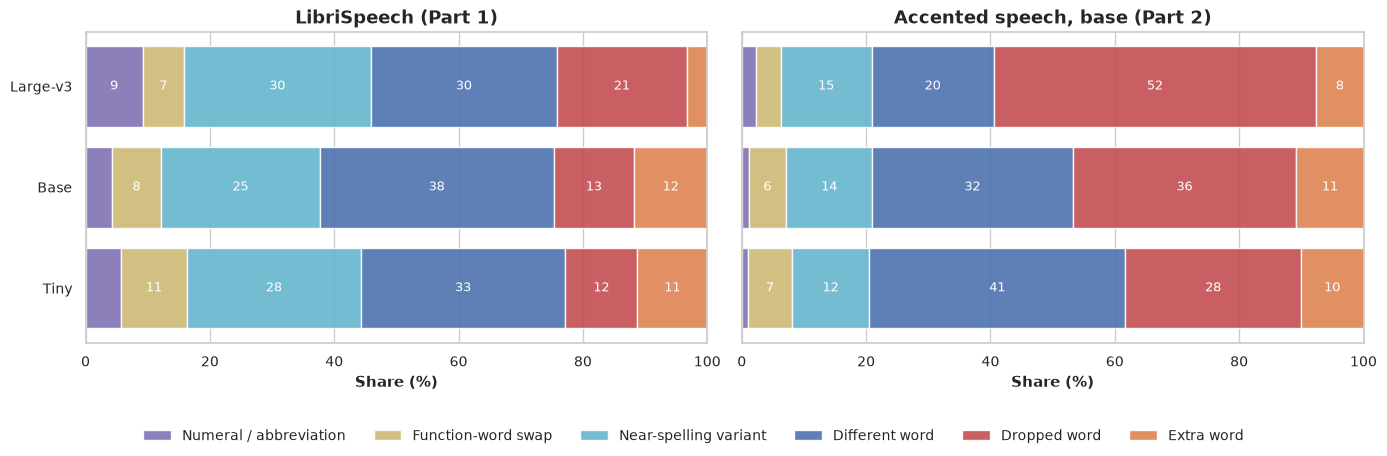

In [19]:
fig = plot_edit_categories(ls_counts.drop(columns="Total edits"), accent_counts.drop(columns="Total edits"))
save_figure(fig, "edit_categories.png")
plt.show()

In [20]:
accent_confusions = pd.concat({model: top_confusions(accent_edits, model, 6) for model in MODEL_ORDER}, names=["Model"]).reset_index(level=0)
accent_confusions

,Model,Kind,Reference word,Hypothesis word,Count
0,Whisper Tiny,delete,i,,21
1,Whisper Tiny,delete,like,,19
2,Whisper Tiny,delete,a,,11
3,Whisper Tiny,delete,the,,11
4,Whisper Tiny,delete,um,,9
5,Whisper Tiny,delete,but,,8
0,Whisper Base,delete,i,,21
1,Whisper Base,delete,like,,15
2,Whisper Base,delete,the,,11
3,Whisper Base,delete,um,,11


In [21]:
drops = {}
for (model, accent), group in df_typical.groupby(["Model", "Accent"]):
    edits = build_edit_table(group, "Model", "Reference", "Base Hypothesis")
    drops[(model, accent)] = {"Total edits": len(edits), "Dropped words": int((edits["Category"] == "Dropped word").sum())}
drops_table = pd.DataFrame.from_dict(drops, orient="index", dtype="int64").unstack(0).reindex(columns=pd.MultiIndex.from_product([["Total edits", "Dropped words"], MODEL_ORDER]))
drops_table

Total edits                               Dropped words                              
            Whisper Tiny Whisper Base Whisper Large-v3  Whisper Tiny Whisper Base Whisper Large-v3
British              770          635              430           316          327              287
Indian               195          167               63            10           21                2
Singaporean          275          205               82            24           14                9

In [22]:
reference_style = df_accent.groupby("Accent")["Reference"].agg(**{
    "Mean reference words": lambda refs: refs.str.split().str.len().mean(),
    "References with <TAG> markers": lambda refs: refs.str.contains("<[A-Z]+>").sum()
}).round(1)
reference_style

,Mean reference words,References with <TAG> markers
Accent,,
British,28.5,33
Indian,9.0,0
Singaporean,10.5,0


In [23]:
hard_base = pd.concat([pick_examples(df_typical, model, "Base WER (%)", 2) for model in MODEL_ORDER])
hard_base[["Model", "Accent", "Base WER (%)", "Reference", "Base Hypothesis"]]

,Model,Accent,Base WER (%),Reference,Base Hypothesis
131,Whisper Tiny,Indian,100.0,His vanity is colossal.,is BANETY'S COOLO SON
124,Whisper Tiny,Indian,100.0,In the post-orange-juice era?,In the post or in this era
370,Whisper Base,Singaporean,100.0,Cancelled projects are in italics.,Cancel project signing eye tactics.
431,Whisper Base,Indian,100.0,His vanity is colossal.,"It's banities, kula san."
735,Whisper Large-v3,Indian,100.0,I'm an entry-level clerk.,I am an entry level clerk
731,Whisper Large-v3,Indian,75.0,His vanity is colossal.,It's Vanity's Colossal


In [24]:
runaway = df_accent.sort_values("Base WER (%)", ascending=False).groupby("Model").head(1)
runaway[["Model", "Accent", "Base WER (%)", "Reference"]].assign(**{"Base Hypothesis": runaway["Base Hypothesis"].str[:110] + "..."})

,Model,Accent,Base WER (%),Reference,Base Hypothesis
532,Whisper Base,British,4228.57,ALMOST ALMOST CERTAINLY WENT A TAD INSANE,"my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my soul, my..."
228,Whisper Tiny,British,398.08,YEAH NO IT'S GREAT IT STARTED LIKE MAYBE LIKE FIVE OR SIX YEARS AGO MY SISTER WAS LIKE ''OH LET'S WATCH DIE HARD'' AND THEN I ...,"Yeah, no, it's great. So I did like maybe like five or six years ago. My sister was like, Oh, that's which tim..."
735,Whisper Large-v3,Indian,100.00,I'm an entry-level clerk.,I am an entry level clerk...


**Reading the Part 2 tables and figure**

- **A few loops set the base mean too.** Excluding the WER > 100% samples, mean base WER falls from 29.6 to 26.2 for Tiny and from 34.8 to 20.4 for Base (Large-v3 has none). The worst Base clip is `British` sample 33, where "ALMOST ALMOST CERTAINLY WENT A TAD INSANE" became "my soul, my soul, my soul, ...".
- **Substitutions shrink with size; dropped words do not.** Excluding the runaways, substitutions are 765 (Tiny), 536 (Base) and 233 (Large-v3) edits, but dropped words are 350, 362 and 298. For Large-v3 that makes deletions 52% of its edits.
- **The dropped words are a dataset effect.** The most common dropped words are the same for all three models: *i*, *like*, *um*, *you*. In the dropped-words table, 287 of Large-v3's 298 dropped words come from the British set, whose references are conversational and verbatim (28.5 words on average against 9.0 for Indian and 10.5 for Singaporean, and 33 references carry markers such as `<OVERLAP>` or `<LAUGH>`). The models write clean text, the reference keeps the disfluencies. This is why Large-v3's median WER is 0.0 for Indian and Singaporean speech but 12.1 for British, which is the opposite of what an accent ranking would predict. The accent comparison is therefore confounded with the source dataset (README limitation 2).
- **Accent-specific mistakes are on rare words.** On the short read sentences, the hardest cases are the same for every model: *"His vanity is colossal."* is heard as *"is BANETY'S COOLO SON"* (Tiny), *"It's banities, kula san"* (Base) and *"It's Vanity's Colossal"* (Large-v3, 75% WER). *"Cancelled projects are in italics."* becomes *"Cancel project signing eye tactics."* in Base.
- **Large-v3's worst score is a metric artefact.** Its only 100% WER sample is *"I'm an entry-level clerk."* transcribed as *"I am an entry level clerk"*, which is correct but is scored as four errors: the contraction is split and the normaliser turns *entry-level* into one token. WER understates Large-v3's accuracy on this set; the BERT-F1 of 0.956 is the fairer reading.

### 2. Prompt vs no prompt

Each transcript is labelled by how it failed: *Exact*, *Minor errors* (WER <= 20%), *Heavy errors* (20-100%), *Truncated* (2 words or fewer for a longer reference), *Prompt echo* (the output repeats the prompt), *Repetition loop* (gzip compression ratio above 2.4, the same repetition heuristic Whisper itself uses) and *Runaway* (WER above 100% without a loop).

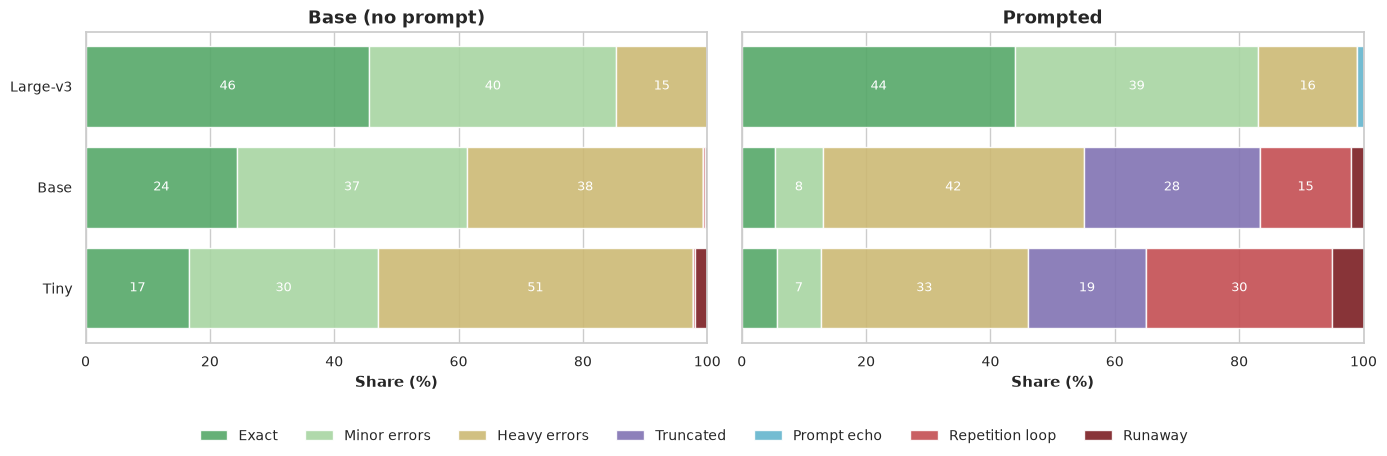

col_0                       Exact  Minor errors  Heavy errors  Truncated  Prompt echo  Repetition loop  Runaway
Condition Model                                                                                                
Base      Whisper Tiny       16.7          30.3          50.7        0.0          0.0              0.3      2.0
          Whisper Base       24.3          37.0          38.0        0.0          0.0              0.3      0.3
          Whisper Large-v3   45.7          39.7          14.7        0.0          0.0              0.0      0.0
Prompted  Whisper Tiny        5.7           7.0          33.3       19.0          0.0             30.0      5.0
          Whisper Base        5.3           7.7          42.0       28.3          0.0             14.7      2.0
          Whisper Large-v3   44.0          39.0          16.0        0.0          1.0              0.0      0.0

In [25]:
base_types = output_type_counts(df_accent, "Base Hypothesis", MODEL_ORDER)
prompted_types = output_type_counts(df_accent, "Prompted Hypothesis", MODEL_ORDER)
fig = plot_output_types(base_types, prompted_types)
save_figure(fig, "output_types.png")
plt.show()
pd.concat({"Base": base_types, "Prompted": prompted_types}, names=["Condition"]).round(1)

**What the prompt does to each model**

- **Tiny and Base:** the share of failed outputs (truncated, loop, runaway or echo) goes from 2% to 54% for Tiny and from 1% to 45% for Base, while exact and minor-error transcripts fall from 47% to 13% (Tiny) and from 61% to 13% (Base).
- **Large-v3:** almost unchanged (exact 45.7% to 44.0%, heavy errors 14.7% to 16.0%). The only failure is a 1% prompt echo.

The tables below are the evidence that this is a failure of the prompted decoding, not of the audio.

In [26]:
df_accent = df_accent.assign(**{
    "Prompted type": [classify_output(ref, hyp) for ref, hyp in zip(df_accent["Reference"], df_accent["Prompted Hypothesis"].fillna(""))]
})
truncated = df_accent[df_accent["Prompted type"] == "Truncated"]
pd.DataFrame({
    "Truncated prompted outputs": truncated.groupby("Model").size().reindex(MODEL_ORDER).fillna(0).astype(int),
    "Median base WER on those clips": truncated.groupby("Model")["Base WER (%)"].median().reindex(MODEL_ORDER).round(1)
})

,Truncated prompted outputs,Median base WER on those clips
Model,,
Whisper Tiny,57,23.5
Whisper Base,85,17.1
Whisper Large-v3,0,NaN


In [27]:
tiny = df_accent[df_accent["Model"] == "Whisper Tiny"]
is_stock_phrase = tiny["Prompted Hypothesis"].str.startswith("The English translation")
pd.Series({
    "Tiny prompted outputs starting 'The English translation'": int(is_stock_phrase.sum()),
    "Median base WER on those same clips": float(tiny.loc[is_stock_phrase, "Base WER (%)"].median()),
    "Distinct prompted outputs of Tiny (of 300)": int(tiny["Prompted Hypothesis"].nunique())
}, dtype="float64")

Tiny prompted outputs starting 'The English translation'     69.0
Median base WER on those same clips                          25.0
Distinct prompted outputs of Tiny (of 300)                  190.0
dtype: float64

In [28]:
broke = df_accent[(df_accent["Base WER (%)"] == 0) & (df_accent["Prompted WER (%)"] > 100)].groupby("Model").head(1)
broke = broke.assign(**{"Prompted Hypothesis": broke["Prompted Hypothesis"].str[:150] + "..."})
broke[["Model", "Accent", "Reference", "Base Hypothesis", "Prompted Hypothesis"]]

,Model,Accent,Reference,Base Hypothesis,Prompted Hypothesis
32,Whisper Tiny,Singaporean,This is a simple consequence of the Lagrange form of the remainder.,This is a simple consequence of the Lagrange form of the remainder.,This is a simple consequence of the Lagrange form of the Lagrange form of the Lagrange form of the Lagrange form of the Lagran...
312,Whisper Base,Singaporean,It is the home of the football team of Harvard.,It is the home of the football team of Harvard.,It is the home of the home of the home of the home of the home of the home of the home of the home of the home of the home of ...


In [29]:
large = df_accent[df_accent["Model"] == "Whisper Large-v3"]
worse = large[large["Prompted WER (%)"] > large["Base WER (%)"] + 30]
better = large[large["Prompted WER (%)"] < large["Base WER (%)"] - 15]
pd.concat({"Prompt hurt": worse.head(3), "Prompt helped": better.head(3)}, names=["Effect"])[["Reference", "Base Hypothesis", "Prompted Hypothesis"]]

Reference  \
Effect                                                                                                                 
Prompt hurt   717                                                                                  Lack of appetite!   
              836  PEOPLE PEOPLE WHEN THEY FIRST CAME OUT PEOPLE MOCKED THEM SO HARD AND NOW THEY'RE JUST EVERYWHERE   
              840                                     THE HELL OUT OF IT BUT THEN THEY NEVER ACTUALLY LIKE MADE THEM   
Prompt helped 608                                          Baldwin himself designed the two storey wood frame house.   
              657                                                            Normally such paper towels are two-ply.   
              690               One confirmed vector of the virus is the phlebotomine sand fly "Lutzomyia shannoni".   

                                                                                                  Base Hypothesis                                                             Prompted Hypothesis  
Effect                                                                                                                                                                                             
Prompt hurt   717                                                                                Like an Appetite                                                               Like an Appendage  
              836  people when they first came out people mocked them so hard and now they're just gonna remember                                                                    I was one of  
              840                                              the hell out of it. They never actually made them.         The following is an English transcription spoken with a British accent.  
Prompt helped 608                                           Bollig himself designed a do-sorry-would-frame house.                            Paul himself designed the Do-Sorry Wood frame house.  
              657                                                           Normally such paper towels are 2 ply.                                         Normally such paper towels are two-ply.  
              690                   One confirmed vector of the virus is the Phlebotomy sandfly Lutzomia shinoni.  One confirmed vector of the virus is the phlebotomy sand fly Lutzomia shinomi.

**Evidence from the outputs**

1. **Audio that was transcribed fine without the prompt.** 57 Tiny and 85 Base prompted outputs are truncated to one or two words (mostly just *"The"*), yet the base transcripts of those same clips had a median WER of only 23.5 and 17.1.
2. **Output unrelated to the audio.** 69 of Tiny's 300 prompted outputs start with *"The English translation"*, typically *"The English translation is a French translation is a French translation..."*, on clips whose base transcript was fine (median WER 25.0). The same sentence is produced for different speakers and sentences (for example for *"These are my top grades."* and *"Byron was born in California."*).
3. **Loops on clips that were exact without the prompt.** The `Lagrange form of the remainder` clip (Tiny) and the `home of the football team of Harvard` clip (Base) both had 0% WER unprompted and became *"...of the Lagrange form of the Lagrange form..."* and *"...the home of the home of the home..."* when prompted.
4. **Large-v3 examples cut both ways.** It is hurt by one conversational British clip where the whole output is the prompt itself ("The following is an English transcription spoken with a British accent."), and by *"Thank you for watching."* on another. It is helped where the prompt's punctuated style happens to match the reference (*two-ply* instead of *2 ply*, *entry-level* with its hyphen). Those gains are formatting, not accent handling, and net median WER still rises from 5.6 to 7.7.

Per-sample view (see the `accuracy_overview` figure above): prompting made 83% of Tiny and 87% of Base samples worse, against 14% worse and 9% better for Large-v3.

#### Why does it happen?

Facts first, then hypotheses. The token table shows how `src/inference.py` builds the prompt (`tokenizer.encode`) next to the method the documentation prescribes (`get_prompt_ids`).

In [30]:
processor = WhisperProcessor.from_pretrained(MODEL_IDS["Whisper Tiny"])
prompt = ACCENT_PROMPTS["indian"]
as_built = processor.tokenizer.convert_ids_to_tokens(processor.tokenizer.encode(prompt))
documented = processor.tokenizer.convert_ids_to_tokens(processor.get_prompt_ids(prompt).tolist())
pd.DataFrame({
    "Method": ["tokenizer.encode(prompt)  (used in src/inference.py)", "processor.get_prompt_ids(prompt)  (documented)"],
    "First tokens": [" ".join(as_built[:4]), " ".join(documented[:3])],
    "Last tokens": [" ".join(as_built[-2:]), " ".join(documented[-2:])]
})

,Method,First tokens,Last tokens
0,tokenizer.encode(prompt) (used in src/inference.py),<|startoftranscript|> <|notimestamps|> The Ġfollowing,. <|endoftext|>
1,processor.get_prompt_ids(prompt) (documented),<|startofprev|> ĠThe Ġfollowing,Ġaccent .


**What the documentation says**

- *Hugging Face `generate` docs:* `prompt_ids` is a "rank-1 tensor of token IDs created by passing text to `get_prompt_ids()`", used "to provide or 'prompt-engineer' a context for transcription, e.g. custom vocabularies or proper nouns". The documented use is vocabulary and proper nouns, not describing the speaker's accent, so there is no documented reason to expect an accent sentence to help.
- *Whisper paper (Radford et al., 2022, section 2.3):* during training, "with some probability we add the transcript text preceding the current audio segment to the decoder's context". The prompt slot is the model's *previous-text* slot, introduced by a dedicated `<|startofprev|>` token. Section 6 lists "getting stuck in repeat loops" and "complete hallucination" as known failure modes; section 4.5 uses a gzip compression ratio above 2.4 to detect repetitive output.
- *`transformers` 5.17 source (`generation_whisper.py`, installed here):* in the short-form path the prompt ids are prepended to the decoder input unchanged (`decoder_input_ids = torch.cat([prev_tokens, decoder_input_ids], dim=-1)`), and the long-form path strips a leading start-of-previous token, which shows that is the token the ids are expected to start with.

**What that means for our run (verified in the token table above)**

`tokenizer.encode(prompt)` returns `<|startoftranscript|> <|notimestamps|> The ... . <|endoftext|>`. The documented `get_prompt_ids` returns `<|startofprev|> The ... .` with a leading space. So our prompt reached the decoder without the start-of-previous token, and with a stray start-of-transcript, no-timestamps and end-of-text token inside the "previous text". That is not the format the model was trained on.

**Hypotheses (consistent with the outputs, not proven)**

- The stray `<|endoftext|>` in the context explains the truncated outputs: the decoder may read the segment as already finished and stop after a word or two.
- A context of an unfamiliar shape pushes the small decoders into language-model behaviour that ignores the audio, which would explain the stock *"The English translation..."* sentence and the repetition loops. Large-v3 being robust fits the paper's general finding that accuracy rises with model size, but neither the paper nor the docs say why a larger model tolerates a bad context.
- The Large-v3 prompt echo and *"Thank you for watching."* fit the "complete hallucination" failure mode the paper names; the docs say nothing specific about them.

**What this analysis does not show.** We did not re-run any model with `get_prompt_ids`, so we cannot say whether a correctly built accent prompt would help, hurt or do nothing. The supported statement is: *this prompt construction hurts Tiny and Base and does not help Large-v3.* The next experiment should re-run a 100-sample subset with `get_prompt_ids` (and ideally a vocabulary-style prompt, which is what the docs describe).

### 3. Recommendation

The table pulls every measure the notebook produced into one view (transposed so the models are columns).

In [31]:
cost = df_cost.set_index("System")
accent_median = df_accent.groupby("Model")[["Base WER (%)", "Prompted WER (%)"]].median()
prompted_failure = prompted_types[["Truncated", "Repetition loop", "Runaway", "Prompt echo"]].sum(axis=1)
recommendation = pd.DataFrame({
    "LibriSpeech WER (%)": df_ls.groupby("Model")["WER (%)"].mean(),
    "Accent median WER (%)": accent_median["Base WER (%)"],
    "Accent BERT-F1": df_bert.groupby("Model")["Base BERT-F1"].mean(),
    "p50 latency (ms)": cost["p50 Latency (ms)"],
    "p95 latency (ms)": cost["p95 Latency (ms)"],
    "RTF": cost["Mean RTF"],
    "Cost / 1,000 h ($)": cost["Cost / 1,000 Audio Hours ($)"],
    "Prompted: median WER (%)": accent_median["Prompted WER (%)"],
    "Prompted: failed outputs (%)": prompted_failure
}).reindex(MODEL_ORDER).round(3)
recommendation.T

,Whisper Tiny,Whisper Base,Whisper Large-v3
LibriSpeech WER (%),10.207,7.818,3.794
Accent median WER (%),22.220,15.380,5.560
Accent BERT-F1,0.921,0.934,0.956
p50 latency (ms),197.350,244.600,1460.850
p95 latency (ms),383.535,492.375,2677.620
RTF,0.041,0.052,0.303
"Cost / 1,000 h ($)",20.683,26.399,285.999
Prompted: median WER (%),97.985,83.330,7.690
Prompted: failed outputs (%),54.000,45.000,1.000


**Default: Whisper Large-v3, no accent prompt.**

| If the priority is... | Use | Why (from the table above) |
|---|---|---|
| Accuracy, accented or challenging audio, text read by people or fed to NLP | **Large-v3** | LibriSpeech WER 3.8% against 7.8% (Base) and 10.2% (Tiny); accent median WER 5.6 against 15.4 and 22.2; BERT-F1 0.956. It degrades least on hard audio (1.7x worse on the challenging split against about 3x for the small models). |
| Low cost or latency where a rough transcript is enough (search, tagging, drafts with review) | **Base** | About 6x faster (RTF 0.052 against 0.303) and about 11x cheaper ($26 against $286 per 1,000 audio hours) than Large-v3, with two to three times the WER (7.8% on LibriSpeech, median 15.4 on accented speech). |
| Almost never | **Tiny** | Only 47 ms faster at p50 and $5.7 cheaper per 1,000 hours than Base, for 30% more LibriSpeech WER (10.2 against 7.8) and a 44% higher accent median WER (22.2 against 15.4). Base dominates it. |

**Scale check.** At the config's reference rates, Large-v3 costs about $0.29 per audio hour. Even at 100,000 hours a year that is roughly $29,000 against $2,600 for Base, so the accuracy gain is usually worth the price unless volume is very large.

**Latency.** Large-v3 takes 1.46 s at p50 and 2.68 s at p95 per clip on the benchmark hardware, so it suits batch or near-real-time use. If responses must arrive in a few hundred milliseconds, or the deployment GPU has less than about 10 GB of memory, use Base; this benchmark did not test streaming.

**Do not use the accent prompt as built here.** It leaves Large-v3 unchanged at best (median WER 5.6 to 7.7) and breaks more than half of Tiny's and nearly half of Base's outputs (54% and 45%). Treat the result as a warning about this construction, not about prompting in general, until the `get_prompt_ids` re-run described above has been done.

**Caveats that bound this advice**

- 100 samples per accent, and the British set comes from a different, conversational dataset, so accent-by-accent rankings are unreliable; the model ranking is not, because it holds on both LibriSpeech and the accented data.
- WER carries artefacts (digits against number words, hyphens, contractions) that mostly penalise Large-v3; BERT-F1 agrees with the ranking.
- Latency and cost are sequential, single-request figures on one machine, using AWS on-demand reference prices from `config.py` that should be checked before budgeting.